In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path = "/Users/brianlerner/Library/CloudStorage/OneDrive-DukeUniversity/Code/cerebra/src/llm/testing/extraction_single_fidelity/search_results_llm_v1.csv"


In [154]:

# BE MINDFUL OF THE INDEXING
df = pd.read_csv(path)
ind_levels = ['arg_type', 'trial', 'arg_index']
df = df.set_index(ind_levels)

# pring avg search time with std
avg_search_time = df['search_time'].mean()
std_search_time = df['search_time'].std()
print(f"Average search time: {avg_search_time:.2f} s +/- {std_search_time:.2f} s")

n_total = df.index.nunique() # the number of individual searches 
print(f"Total number of searches: {n_total}")

# get the number of event searches
n_event = df.xs('v', level='arg_type').index.nunique()
print(f"Number of event searches: {n_event}")
# get the number of people searches
n_person = df.xs('p', level='arg_type').index.nunique()
print(f"Number of person searches: {n_person}")


closest_correct = df[(df['arg_inp']==df['e_base'])& (df['nearest_index']==0)]
n_closest_correct = closest_correct.shape[0]
print(f"Number of searches that have the closest neighbor correct: {n_closest_correct}")

frac_not_closest_correct = 1 - n_closest_correct/n_total
print(f"Fraction of searches that do not have the closest neighbor correct: {frac_not_closest_correct:.2f}")

# 
# for at, g_at in df.set_index(['trial', 'arg_index']).groupby("arg_type"):
    # display(g_at)



Average search time: 1.50 s +/- 7.08 s
Total number of searches: 181
Number of event searches: 100
Number of person searches: 81
Number of searches that have the closest neighbor correct: 177
Fraction of searches that do not have the closest neighbor correct: 0.02


In [160]:
# get the searches that do not have the closest correct neighbro
df[~df.index.isin(closest_correct.index)]

nearest_index  \
arg_type trial arg_index                  
v        12    0                      0   
               0                      1   
               0                      2   
               0                      3   
               0                      4   
         31    0                      0   
               0                      1   
               0                      2   
               0                      3   
               0                      4   
         44    0                      0   
               0                      1   
               0                      2   
               0                      3   
               0                      4   
         95    0                      0   
               0                      1   
               0                      2   
               0                      3   
               0                      4   

                                                         arg_inp  \
arg_type trial arg_index                                           
v        12    0                      basketball game (activity)   
               0                      basketball game (activity)   
               0                      basketball game (activity)   
               0                      basketball game (activity)   
               0                      basketball game (activity)   
         31    0          class: Computer Programming (activity)   
               0          class: Computer Programming (activity)   
               0          class: Computer Programming (activity)   
               0          class: Computer Programming (activity)   
               0          class: Computer Programming (activity)   
         44    0          class: Computer Programming (activity)   
               0          class: Computer Programming (activity)   
               0          class: Computer Programming (activity)   
               0          class: Computer Programming (activity)   
               0          class: Computer Programming (activity)   
         95    0                      basketball game (activity)   
               0                      basketball game (activity)   
               0                      basketball game (activity)   
               0                      basketball game (activity)   
               0                      basketball game (activity)   

                                                        arg_out  \
arg_type trial arg_index                                          
v        12    0                             playing basketball   
               0                             playing basketball   
               0                             playing basketball   
               0                             playing basketball   
               0                             playing basketball   
         31    0          Computer Programming class attendance   
               0          Computer Programming class attendance   
               0          Computer Programming class attendance   
               0          Computer Programming class attendance   
               0          Computer Programming class attendance   
         44    0          Computer Programming class attendance   
               0          Computer Programming class attendance   
               0          Computer Programming class attendance   
               0          Computer Programming class attendance   
               0          Computer Programming class attendance   
         95    0                             playing basketball   
               0                             playing basketball   
               0                             playing basketball   
               0                             playing basketball   
               0                             playing basketball   

                                                                 e_base  \
arg_type trial arg_index        

/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_63549/3869227590.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closest_two_all['less_thresh'] = closest_two_all['distance']<thresh


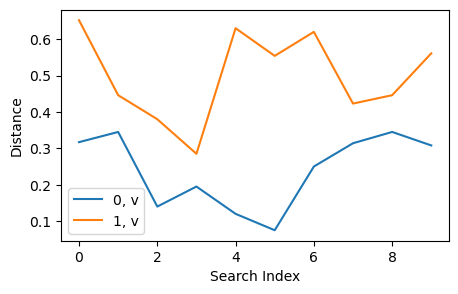

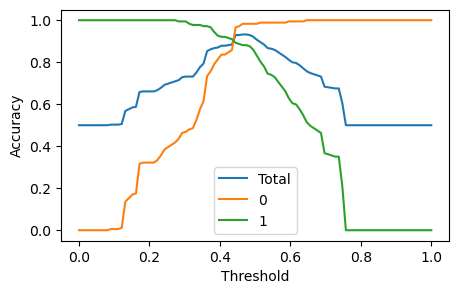

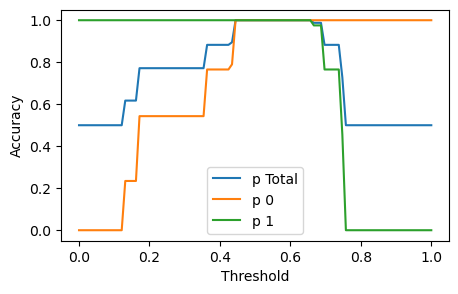

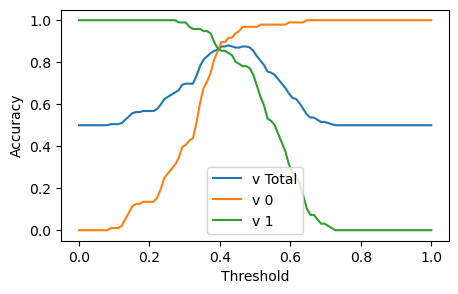

In [161]:
# now use closest_correct.index to index into the original dataframe to get the correct searches
correct_searches = df.loc[closest_correct.index]
closest_two_all = correct_searches[correct_searches['nearest_index']<=1]
# plot the distributions of nearest_index=0 and nearest_index=1
# plot a separate distribution for each index

plt.figure(figsize=(5,3))
for at, g_at in closest_two.groupby("arg_type"):
    # make plot smaller
    first = g_at[g_at['nearest_index']==0]
    second = g_at[g_at['nearest_index']==1]
    plt.plot(first['distance'].values, label=f'0, {at}')
    plt.plot(second['distance'].values, label=f'1, {at}')
    plt.xlabel('Search Index')
    plt.ylabel('Distance')
    plt.legend()
    # first = correct_searches[correct_searches['nearest_index']==0]
    # second = correct_searches[correct_searches['nearest_index']==1]
    # plt.plot(first['distance'].values, label='nearest_index=0')
    # plt.plot(second['distance'].values, label='nearest_index=1')

# now, let's find the optimal threshold
thresholds = np.linspace(0, 1, 100)

accs = []
first_accs = []
second_accs = []
for thresh in thresholds:
    closest_two_all['less_thresh'] = closest_two_all['distance']<thresh
    first_correct = closest_two_all[closest_two_all['nearest_index']==0]['less_thresh'].sum()
    second_correct = (~closest_two_all[closest_two_all['nearest_index']==1]['less_thresh']).sum()
    acc = (first_correct + second_correct)/closest_two_all.shape[0]
    first_acc = first_correct/closest_two_all[closest_two_all['nearest_index']==0].shape[0]
    second_acc = second_correct/closest_two_all[closest_two_all['nearest_index']==1].shape[0]
    accs.append(acc)
    first_accs.append(first_acc)
    second_accs.append(second_acc)
plt.figure(figsize=(5,3))
plt.plot(thresholds, accs, label=f'Total')
plt.plot(thresholds, first_accs, label=f'0')
plt.plot(thresholds, second_accs, label=f'1')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

acc_dict = {}
for at, closest_two in closest_two_all.groupby("arg_type"):
    accs = []
    first_accs = []
    second_accs = []
    for thresh in thresholds:
        closest_two['less_thresh'] = closest_two['distance']<thresh
        first_correct = closest_two[closest_two['nearest_index']==0]['less_thresh'].sum()
        second_correct = (~closest_two[closest_two['nearest_index']==1]['less_thresh']).sum()
        acc = (first_correct + second_correct)/closest_two.shape[0]
        first_acc = first_correct/closest_two[closest_two['nearest_index']==0].shape[0]
        second_acc = second_correct/closest_two[closest_two['nearest_index']==1].shape[0]
        accs.append(acc)
        first_accs.append(first_acc)
        second_accs.append(second_acc)
    acc_dict[at] = np.array(accs)
    plt.figure(figsize=(5,3))
    plt.plot(thresholds, accs, label=f'{at} Total')
    plt.plot(thresholds, first_accs, label=f'{at} 0')
    plt.plot(thresholds, second_accs, label=f'{at} 1')
    plt.xlabel('Threshold')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# now, lets do the same except 


In [149]:
a = np.array([1,2,1,2,0])
len(a)-[::-1])

1

In [162]:
for at, accs in acc_dict.items():
    # find the max accuracy
    max_acc = np.max(accs)
    # see if the max occurs multiple times; if so, get the median index
    max_idxs = np.where(accs==max_acc)
    median_idx = np.median(max_idxs)
    # get the threshold
    threshold = thresholds[int(median_idx)]
    print(f"Max accuracy for {at}: {max_acc:.2f} at threshold: {threshold:.2f}")
    

Max accuracy for p: 1.00 at threshold: 0.55
Max accuracy for v: 0.88 at threshold: 0.42
